In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()

In [11]:
data = pd.read_csv('Telco-Customer-Churn.csv')

In [12]:
df = data.copy()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.shape

(7043, 21)

In [14]:
pd.to_numeric(df['tenure'])

0        1
1       34
2        2
3       45
4        2
        ..
7038    24
7039    72
7040    11
7041     4
7042    66
Name: tenure, Length: 7043, dtype: int64

In [15]:
df['tenure'].isna().any()

np.False_

In [16]:
# pd.to_numeric(df['TotalCharges'])

## Cleaning

In [17]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [19]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [20]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [21]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [22]:
type(df.TotalCharges[0])

str

In [23]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [26]:
type(df['SeniorCitizen'][0])

numpy.int64

In [27]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [28]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

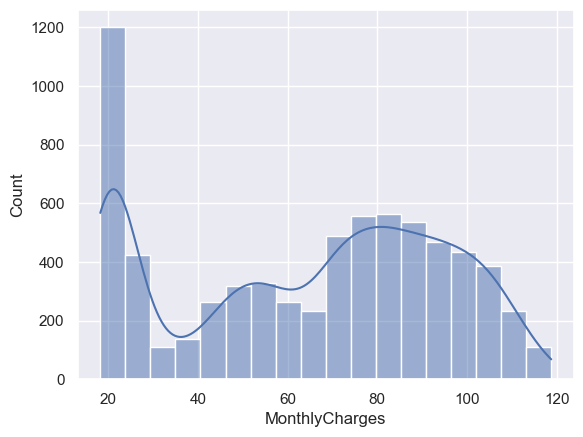

In [29]:
sns.histplot(df['MonthlyCharges'], kde=True)

<Axes: xlabel='TotalCharges', ylabel='Count'>

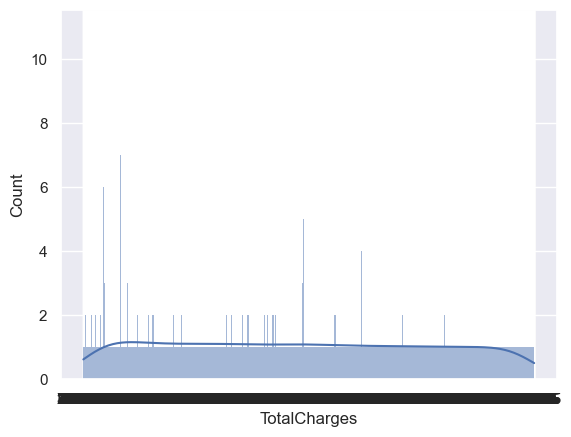

In [30]:
sns.histplot(df['TotalCharges'], kde=True)

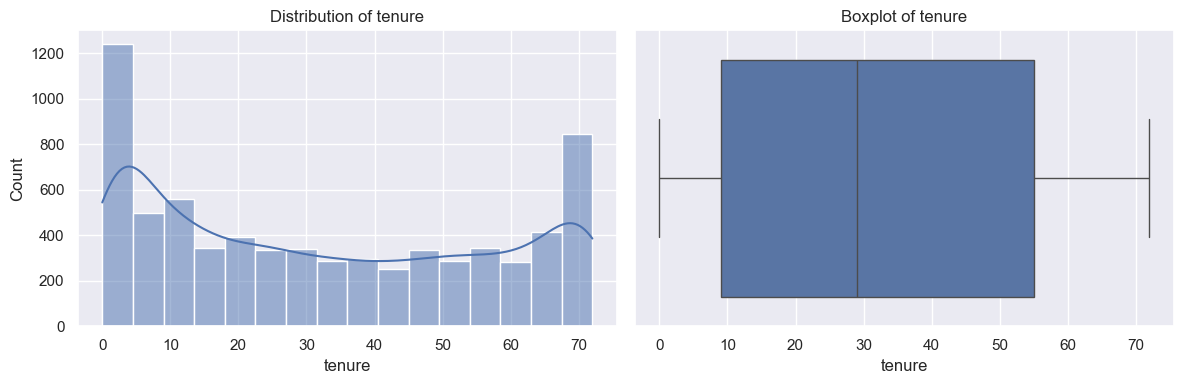

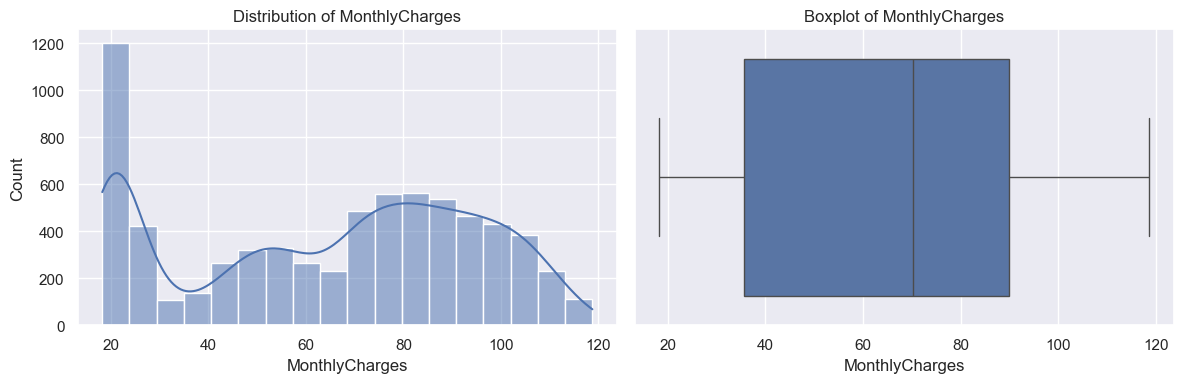

In [31]:
import matplotlib.pyplot as plt
def plot_hist_box(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {column}")
    
    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f"Boxplot of {column}")
    
    plt.tight_layout()
    plt.show()

# Example usage
plot_hist_box(df, "tenure")
plot_hist_box(df, "MonthlyCharges")

## EDA

# Univariate

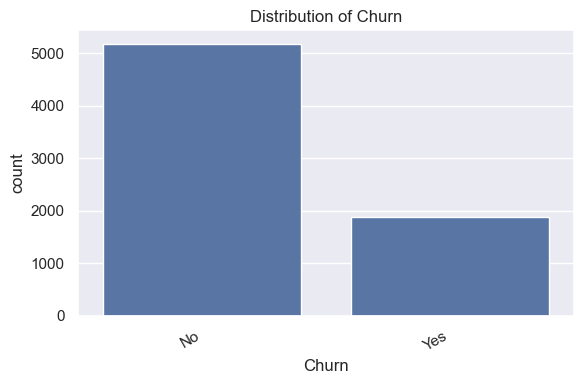

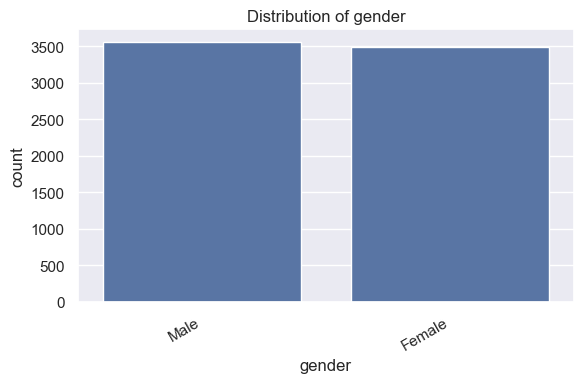

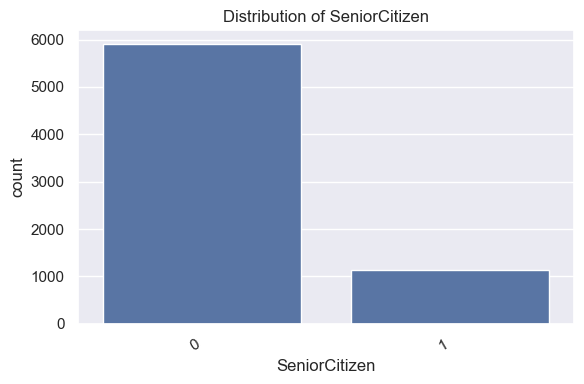

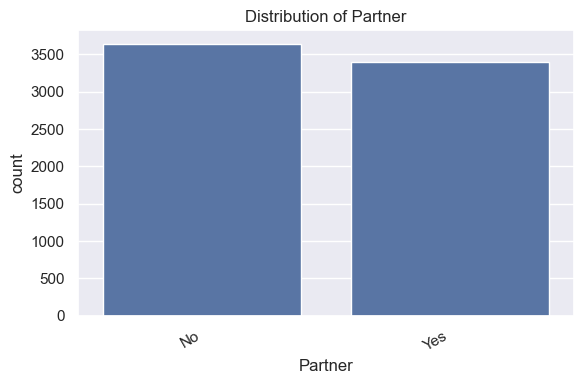

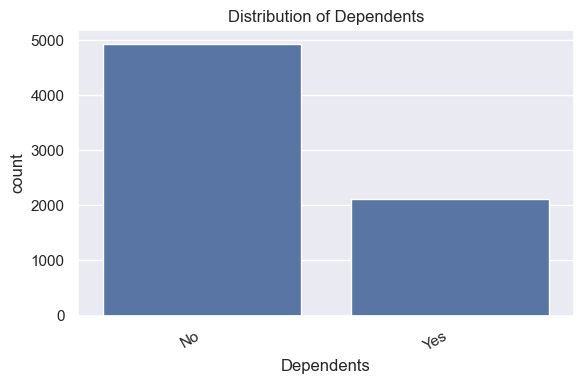

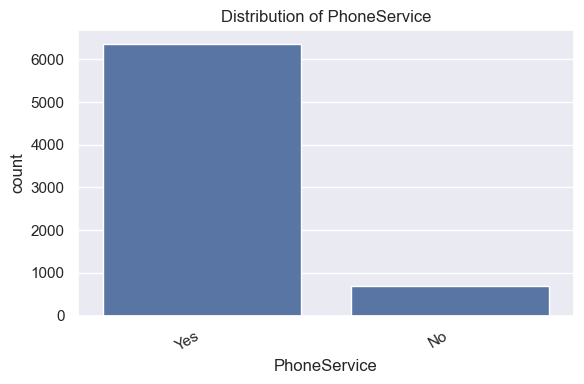

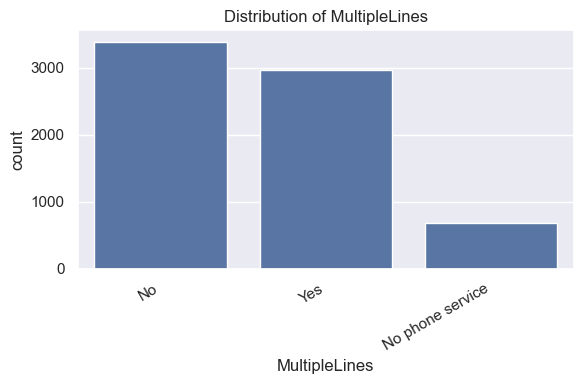

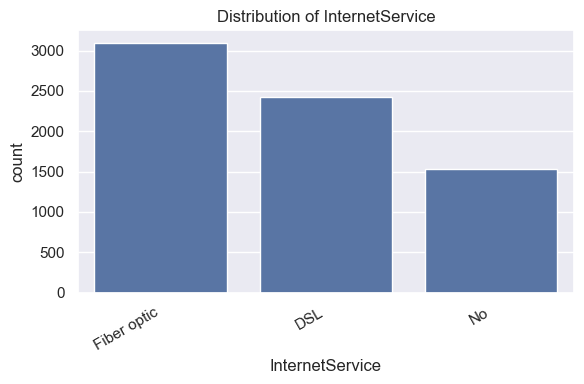

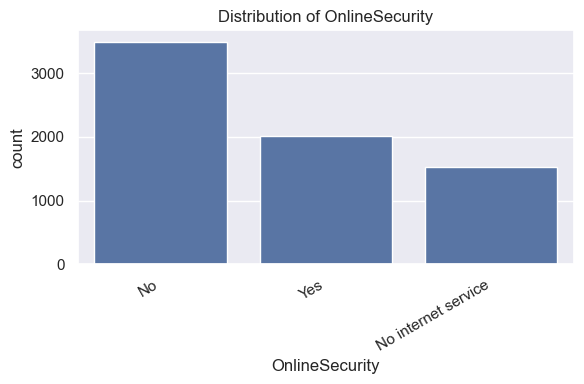

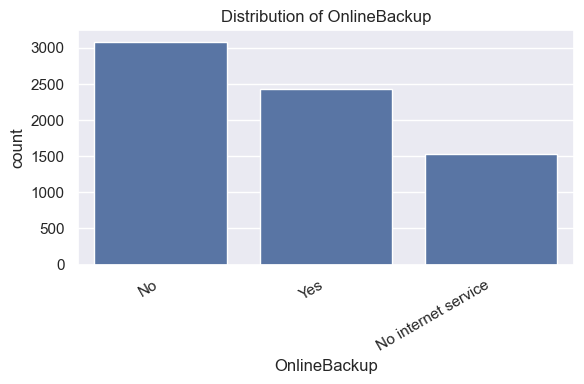

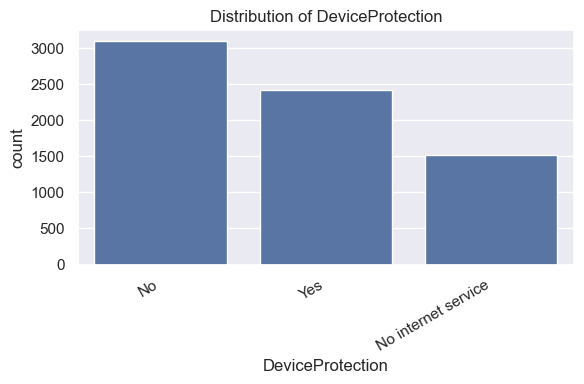

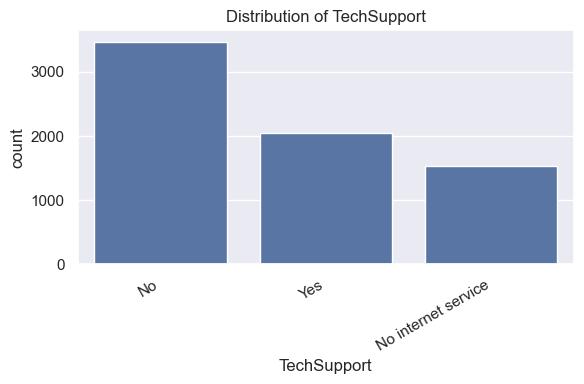

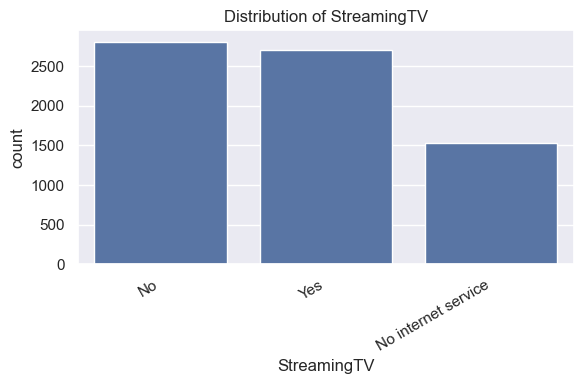

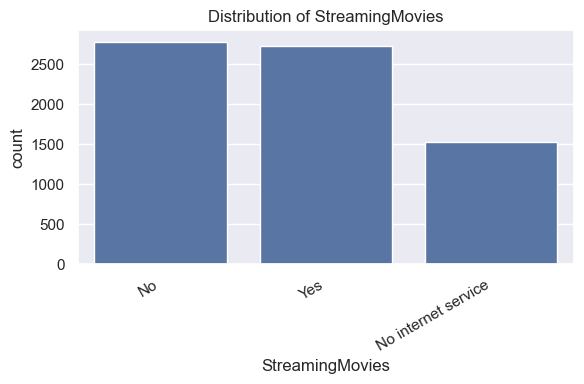

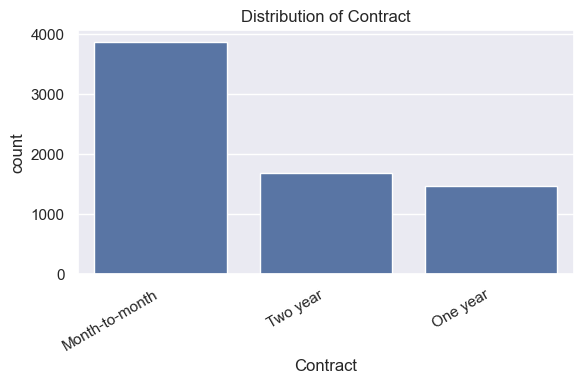

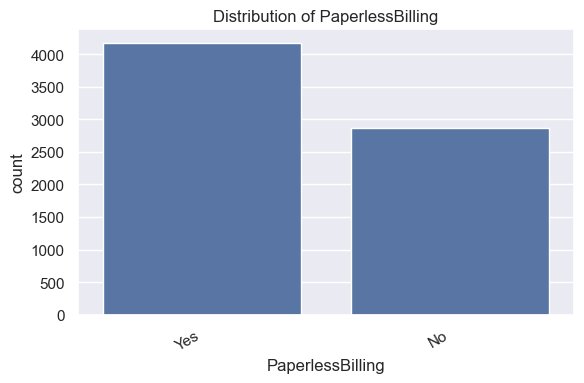

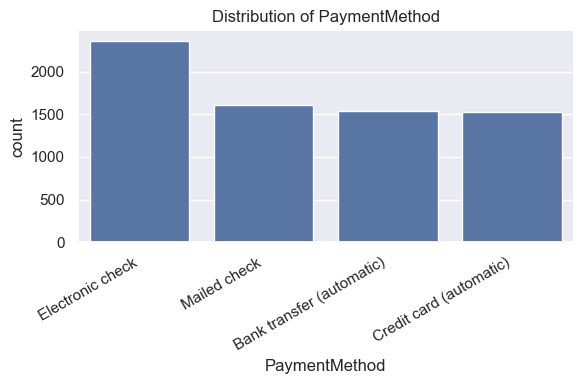

In [32]:
"""
Step 2 (EDA): Univariate bar charts for categorical features.

Plots the distribution (value counts) of each categorical column,
including the target 'Churn' itself, so you can see the shape of
your customer base before relating anything to churn.

Run after loading your cleaned dataframe as `df`.
"""

def plot_categorical_counts(df, column):
    plt.figure(figsize=(6, 4))
    order = df[column].value_counts().index
    sns.countplot(x=df[column], order=order)
    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

categorical_cols = [
    "Churn",  # target — worth seeing the imbalance visually too
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

for col in categorical_cols:
    if col in df.columns:
        plot_categorical_counts(df, col)

# Bivariate

#### Contract vs Churn

In [34]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


#### Tenure vs Churn

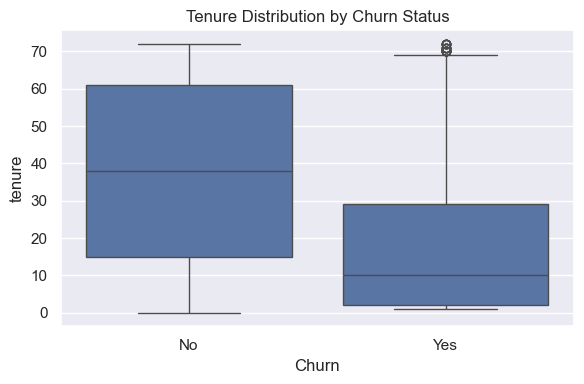

Churn               No       Yes
tenure_group                    
0-12          0.525618  0.474382
13-24         0.712891  0.287109
25-48         0.796110  0.203890
49-72         0.904868  0.095132


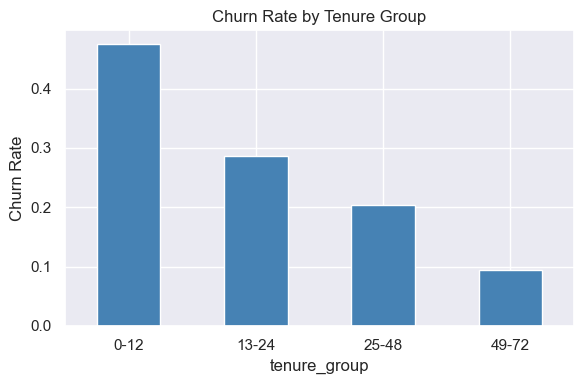

In [37]:

# 1. Boxplot: tenure distribution split by Churn status
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure Distribution by Churn Status")
plt.tight_layout()
plt.show()

# 2. Tenure buckets + churn rate
bins = [0, 12, 24, 48, 72]
labels = ["0-12", "13-24", "25-48", "49-72"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

tenure_churn = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index")
print(tenure_churn)

# Optional: visualize the churn rate by tenure group
tenure_churn["Yes"].plot(kind="bar", figsize=(6, 4), color="steelblue")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Internet Service vs Churn

Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050


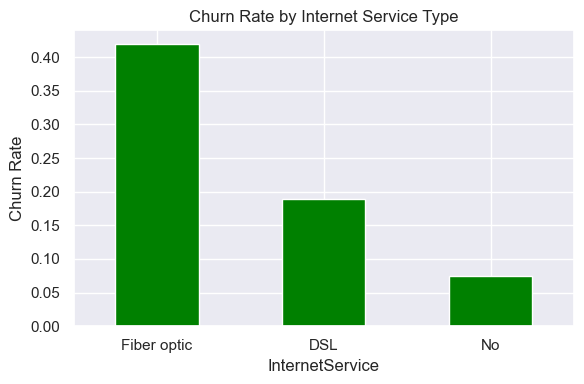

In [38]:
# Crosstab: churn rate within each InternetService category
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index")
print(internet_churn)

# Bar plot of churn rate by InternetService
internet_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar", figsize=(6, 4), color="green"
)
plt.title("Churn Rate by Internet Service Type")
plt.ylabel("Churn Rate")
plt.xlabel("InternetService")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Payment Method vs Churn

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


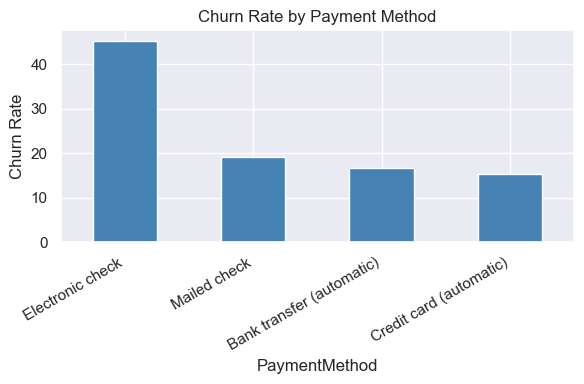

In [39]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
print(payment_churn)

# Bar plot of churn rate by PaymentMethod
payment_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar", figsize=(6, 4), color="steelblue"
)
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xlabel("PaymentMethod")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Monthly Charges vs Churn

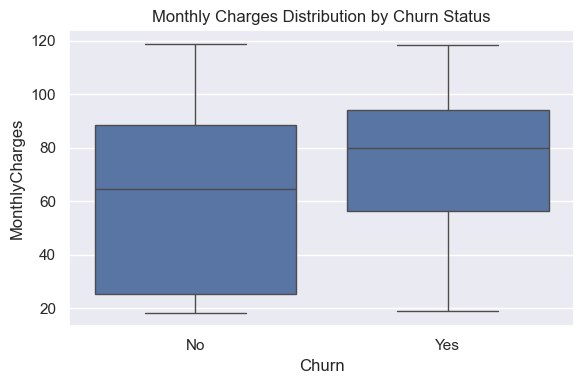

Churn                   No       Yes
charge_group                        
0-35 (low)        0.891066  0.108934
36-70 (mid)       0.760580  0.239420
71-90 (mid-high)  0.622017  0.377983
91-120 (high)     0.672225  0.327775


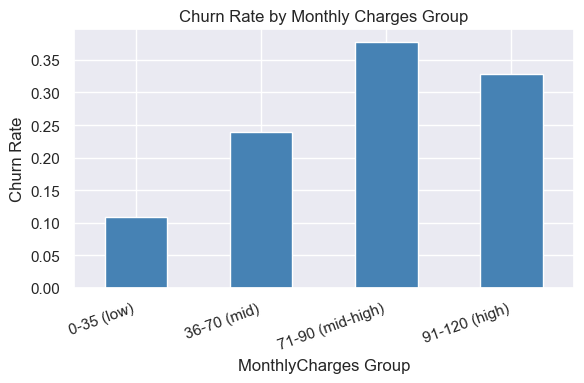

In [40]:
# 1. Boxplot: MonthlyCharges distribution split by Churn status
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges Distribution by Churn Status")
plt.tight_layout()
plt.show()

# 2. MonthlyCharges buckets + churn rate
bins = [0, 35, 70, 90, 120]
labels = ["0-35 (low)", "36-70 (mid)", "71-90 (mid-high)", "91-120 (high)"]
df["charge_group"] = pd.cut(df["MonthlyCharges"], bins=bins, labels=labels, include_lowest=True)

charge_churn = pd.crosstab(df["charge_group"], df["Churn"], normalize="index")
print(charge_churn)

# Optional: visualize churn rate by charge group
charge_churn["Yes"].plot(kind="bar", figsize=(6, 4), color="steelblue")
plt.title("Churn Rate by Monthly Charges Group")
plt.ylabel("Churn Rate")
plt.xlabel("MonthlyCharges Group")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

#### Addons vs Churn


--- OnlineSecurity vs Churn ---
Churn                      No       Yes
OnlineSecurity                         
No                   0.582333  0.417667
No internet service  0.925950  0.074050
Yes                  0.853888  0.146112

--- OnlineBackup vs Churn ---
Churn                      No       Yes
OnlineBackup                           
No                   0.600712  0.399288
No internet service  0.925950  0.074050
Yes                  0.784685  0.215315

--- DeviceProtection vs Churn ---
Churn                      No       Yes
DeviceProtection                       
No                   0.608724  0.391276
No internet service  0.925950  0.074050
Yes                  0.774979  0.225021

--- TechSupport vs Churn ---
Churn                      No       Yes
TechSupport                            
No                   0.583645  0.416355
No internet service  0.925950  0.074050
Yes                  0.848337  0.151663

--- StreamingTV vs Churn ---
Churn                      No       Yes
S

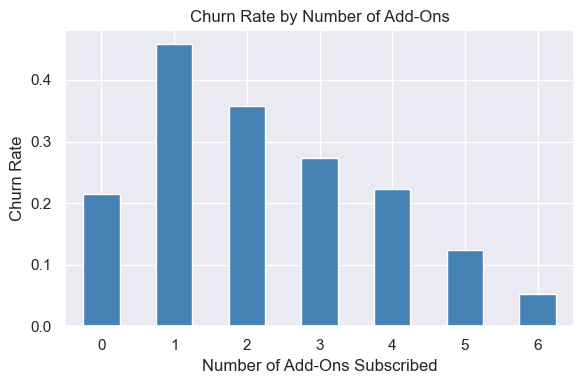

In [41]:
addon_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

# Loop through each add-on and print its churn crosstab
for col in addon_cols:
    print(f"\n--- {col} vs Churn ---")
    print(pd.crosstab(df[col], df["Churn"], normalize="index"))

# Combined add-on count (only counts "Yes", ignores "No" and "No internet service")
df["TotalAddOns"] = (df[addon_cols] == "Yes").sum(axis=1)

addon_count_churn = pd.crosstab(df["TotalAddOns"], df["Churn"], normalize="index")
print("\n--- TotalAddOns vs Churn ---")
print(addon_count_churn)

# Visualize churn rate by add-on count
addon_count_churn["Yes"].plot(kind="bar", figsize=(6, 4), color="steelblue")
plt.title("Churn Rate by Number of Add-Ons")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Add-Ons Subscribed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Total number of Addons (without phone only customers) vs Churn

Churn              No       Yes
TotalAddOns                    
0            0.477633  0.522367
1            0.542443  0.457557
2            0.641820  0.358180
3            0.726297  0.273703
4            0.776995  0.223005
5            0.875657  0.124343
6            0.947183  0.052817


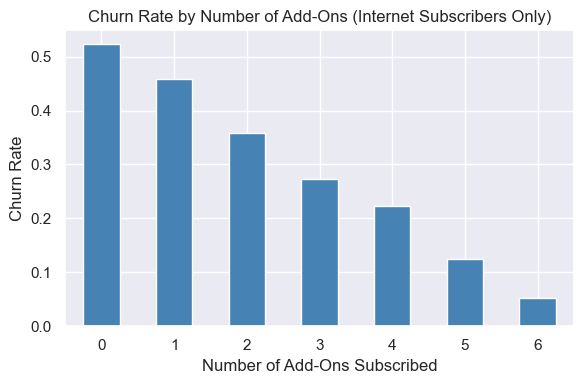

In [42]:
# Restrict to internet subscribers only (exclude phone-only customers)
internet_customers = df[df["InternetService"] != "No"]

addon_count_churn_clean = pd.crosstab(
    internet_customers["TotalAddOns"], internet_customers["Churn"], normalize="index"
)
print(addon_count_churn_clean)

addon_count_churn_clean["Yes"].plot(kind="bar", figsize=(6, 4), color="steelblue")
plt.title("Churn Rate by Number of Add-Ons (Internet Subscribers Only)")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Add-Ons Subscribed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Multivariate Analysis

#### Fiber optic vs Contract type vs Churn

In [43]:
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

Churn                                 No       Yes
InternetService Contract                          
DSL             Month-to-month  0.677841  0.322159
                One year        0.907018  0.092982
                Two year        0.980892  0.019108
Fiber optic     Month-to-month  0.453947  0.546053
                One year        0.807050  0.192950
                Two year        0.927739  0.072261
No              Month-to-month  0.811069  0.188931
                One year        0.975275  0.024725
                Two year        0.992163  0.007837


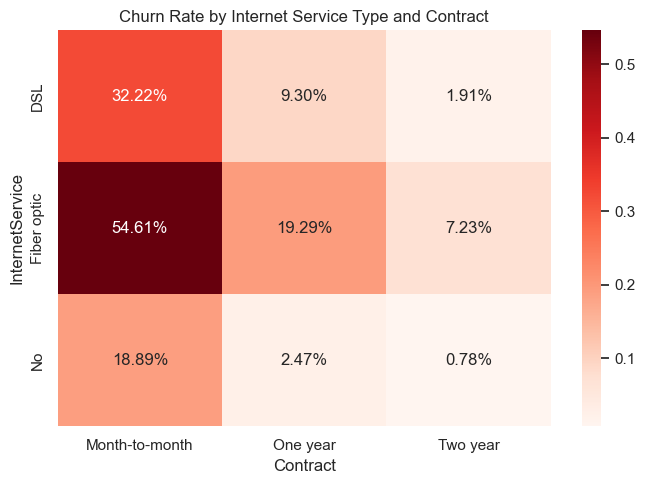

In [44]:

# Two-way crosstab: churn rate for every InternetService x Contract combination
combo_churn = pd.crosstab(
    [df["InternetService"], df["Contract"]], df["Churn"], normalize="index"
)
print(combo_churn)

# Reshape for a heatmap: rows = InternetService, columns = Contract, values = churn rate
heatmap_data = df.pivot_table(
    index="InternetService", columns="Contract", values="Churn_Flag", aggfunc="mean"
)

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2%", cmap="Reds")
plt.title("Churn Rate by Internet Service Type and Contract")
plt.tight_layout()
plt.show()

In [45]:
df.dtypes["TotalCharges"]

dtype('O')

In [46]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [47]:
df.dtypes['TotalCharges']

dtype('float64')

#### Payment Method vs Contract vs Churn

Churn                                           No       Yes
PaymentMethod             Contract                          
Bank transfer (automatic) Month-to-month  0.658744  0.341256
                          One year        0.902813  0.097187
                          Two year        0.966312  0.033688
Credit card (automatic)   Month-to-month  0.672192  0.327808
                          One year        0.896985  0.103015
                          Two year        0.977625  0.022375
Electronic check          Month-to-month  0.462703  0.537297
                          One year        0.815562  0.184438
                          Two year        0.922619  0.077381
Mailed check              Month-to-month  0.684211  0.315789
                          One year        0.931751  0.068249
                          Two year        0.992147  0.007853


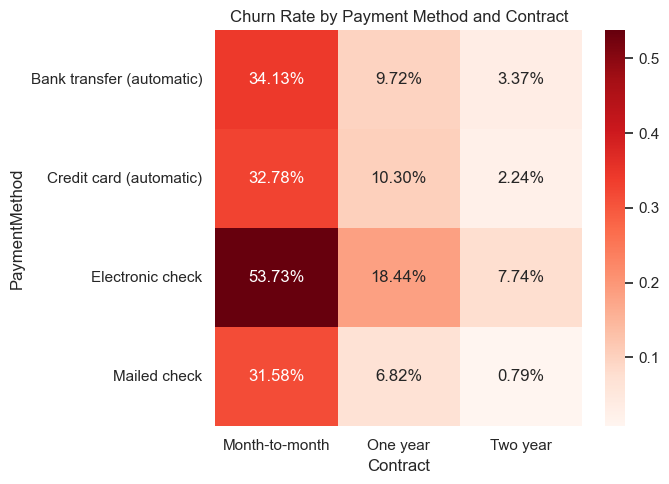

In [48]:
# Two-way crosstab: churn rate for every PaymentMethod x Contract combination
combo_churn = pd.crosstab(
    [df["PaymentMethod"], df["Contract"]], df["Churn"], normalize="index"
)
print(combo_churn)

# Heatmap version
heatmap_data = df.pivot_table(
    index="PaymentMethod", columns="Contract", values="Churn_Flag", aggfunc="mean"
)

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2%", cmap="Reds")
plt.title("Churn Rate by Payment Method and Contract")
plt.tight_layout()
plt.show()

#### Payment Method vs Internet service vs Churn

Churn                                            No       Yes
PaymentMethod             InternetService                    
Bank transfer (automatic) DSL              0.906360  0.093640
                          Fiber optic      0.710526  0.289474
                          No               0.945783  0.054217
Credit card (automatic)   DSL              0.878788  0.121212
                          Fiber optic      0.747069  0.252931
                          No               0.972810  0.027190
Electronic check          DSL              0.680556  0.319444
                          Fiber optic      0.467712  0.532288
                          No               0.877049  0.122951
Mailed check              DSL              0.792822  0.207178
                          Fiber optic      0.573643  0.426357
                          No               0.904184  0.095816


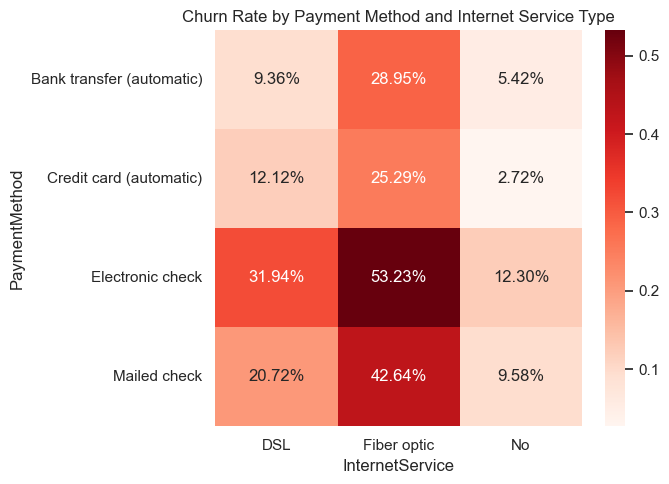

In [49]:
# Two-way crosstab: churn rate for every PaymentMethod x InternetService combination
combo_churn = pd.crosstab(
    [df["PaymentMethod"], df["InternetService"]], df["Churn"], normalize="index"
)
print(combo_churn)

# Heatmap version
heatmap_data = df.pivot_table(
    index="PaymentMethod", columns="InternetService", values="Churn_Flag", aggfunc="mean"
)

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2%", cmap="Reds")
plt.title("Churn Rate by Payment Method and Internet Service Type")
plt.tight_layout()
plt.show()

#### Tenure vs Contract vs Churn

Churn                              No       Yes
Contract       tenure_group                    
Month-to-month 0-12          0.486459  0.513541
               13-24         0.622795  0.377205
               25-48         0.670823  0.329177
               49-72         0.739766  0.260234
One year       0-12          0.895161  0.104839
               13-24         0.918782  0.081218
               25-48         0.893822  0.106178
               49-72         0.870662  0.129338
Two year       0-12          1.000000  0.000000
               13-24         1.000000  0.000000
               25-48         0.978102  0.021898
               49-72         0.966746  0.033254
Churn                          No   Yes
Contract       tenure_group            
Month-to-month 0-12           970  1024
               13-24          459   278
               25-48          538   264
               49-72          253    89
One year       0-12           111    13
               13-24          181    16
        

C:\Users\USER\AppData\Local\Temp\ipykernel_12924\1002628307.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(


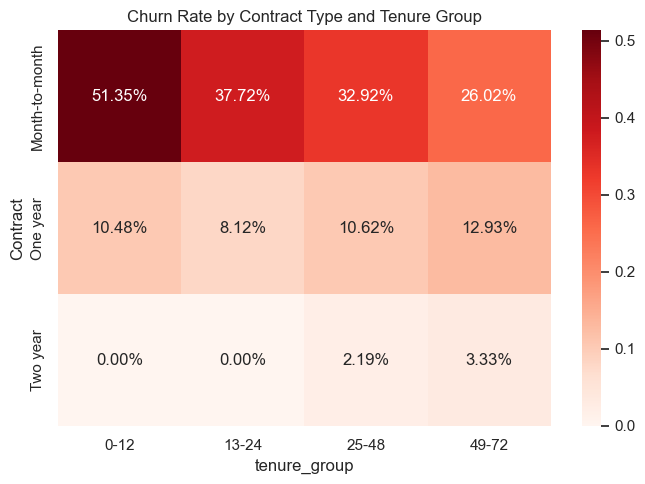

In [50]:

# Reuse the tenure_group column created earlier
combo_churn = pd.crosstab(
    [df["Contract"], df["tenure_group"]], df["Churn"], normalize="index"
)
print(combo_churn)

# Raw counts too, to check cell reliability
combo_counts = pd.crosstab([df["Contract"], df["tenure_group"]], df["Churn"])
print(combo_counts)

# Heatmap version
heatmap_data = df.pivot_table(
    index="Contract", columns="tenure_group", values="Churn_Flag", aggfunc="mean"
)

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2%", cmap="Reds")
plt.title("Churn Rate by Contract Type and Tenure Group")
plt.tight_layout()
plt.show()

#### Partner vs Dependents vs Churn rate

Churn                       No       Yes
HouseholdType                           
Dependents only       0.786704  0.213296
Neither               0.657622  0.342378
Partner + Dependents  0.857633  0.142367
Partner only          0.745917  0.254083
Churn                   No   Yes
HouseholdType                   
Dependents only        284    77
Neither               2157  1123
Partner + Dependents  1500   249
Partner only          1233   420


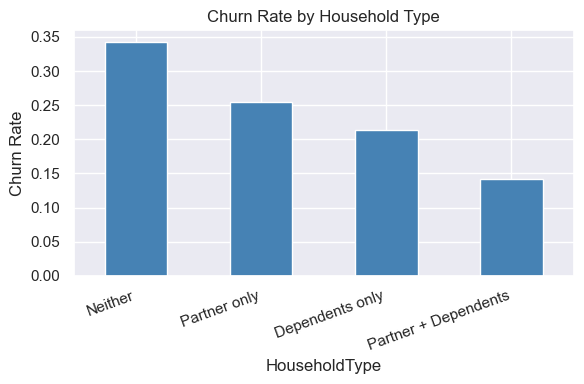

In [51]:
# Combine Partner and Dependents into one household structure variable
def household_type(row):
    if row["Partner"] == "Yes" and row["Dependents"] == "Yes":
        return "Partner + Dependents"
    elif row["Partner"] == "Yes" and row["Dependents"] == "No":
        return "Partner only"
    elif row["Partner"] == "No" and row["Dependents"] == "Yes":
        return "Dependents only"
    else:
        return "Neither"

df["HouseholdType"] = df.apply(household_type, axis=1)

# Churn rate by household type, with counts for reliability check
print(pd.crosstab(df["HouseholdType"], df["Churn"], normalize="index"))
print(pd.crosstab(df["HouseholdType"], df["Churn"]))

# Bar chart
household_churn = pd.crosstab(df["HouseholdType"], df["Churn"], normalize="index")
household_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar", figsize=(6, 4), color="steelblue"
)
plt.title("Churn Rate by Household Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

#### 91-120$ bucket for Monthly Charges vs Addons vs Churn rate

Churn              No       Yes
TotalAddOns                    
2            0.433180  0.566820
3            0.600726  0.399274
4            0.681542  0.318458
5            0.806897  0.193103
6            0.925532  0.074468
Churn         No  Yes
TotalAddOns          
2             94  123
3            331  220
4            336  157
5            234   56
6            174   14


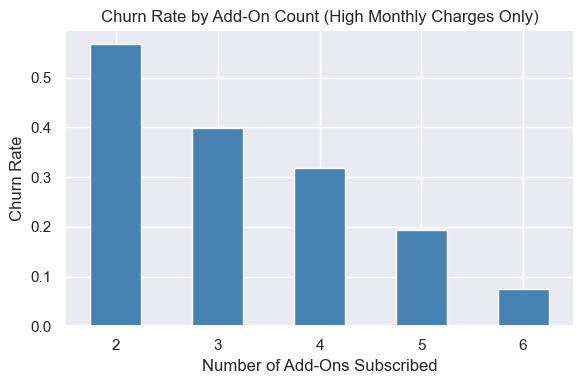

In [52]:
# Filter to just the highest MonthlyCharges bucket
high_charge_customers = df[df["charge_group"] == "91-120 (high)"]

# Churn rate by TotalAddOns count, within the high-charge group only
addon_high_charge = pd.crosstab(
    high_charge_customers["TotalAddOns"], high_charge_customers["Churn"], normalize="index"
)
print(addon_high_charge)

# Raw counts to check reliability
print(pd.crosstab(high_charge_customers["TotalAddOns"], high_charge_customers["Churn"]))

# Bar chart
addon_high_charge["Yes"].plot(kind="bar", figsize=(6, 4), color="steelblue")
plt.title("Churn Rate by Add-On Count (High Monthly Charges Only)")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Add-Ons Subscribed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_group,TotalAddOns,Churn_Flag,HouseholdType
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,0-12,0-35 (low),1,0,Partner only
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,25-48,36-70 (mid),2,0,Neither
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,0-12,36-70 (mid),2,1,Neither
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,25-48,36-70 (mid),3,0,Neither
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,0-12,71-90 (mid-high),0,1,Neither
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Mailed check,84.80,1990.50,No,13-24,71-90 (mid-high),5,0,Partner + Dependents
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Credit card (automatic),103.20,7362.90,No,49-72,91-120 (high),4,0,Partner + Dependents
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,Yes,Electronic check,29.60,346.45,No,0-12,0-35 (low),1,0,Partner + Dependents
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,Yes,Mailed check,74.40,306.60,Yes,0-12,71-90 (mid-high),0,1,Partner only


In [54]:
df.to_csv("churn_data_for_modeling.csv", index=False)

In [56]:
df.dtypes

customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                 object
tenure_group        category
charge_group        category
TotalAddOns            int64
Churn_Flag             int64
HouseholdType         object
dtype: object

In [57]:
df['TotalCharges'].isna().any()

np.False_